In [1]:
import osmnx as ox
import numpy as np
# import networkx as nx

# 1 Graph Management

In [2]:
# Neuer Graph aus bbox laden
G = ox.graph_from_bbox([7.61, 47.48, 7.67, 47.53],network_type='bike', simplify=True, retain_all=True, truncate_by_edge=True)

In [3]:
# Graph speichern, so dass dieser nicht jedesmal geladen werden muss
ox.io.save_graphml(G, filepath='graph/graph.graphml', gephi=False, encoding='utf-8')

In [4]:
# Graph laden
G = ox.io.load_graphml(filepath='C:/Users/tobia/Documents/FHNW/VPRouting/backend/graph/graph.graphml')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\tobia\\Documents\\FHNW\\VPRouting\\backend\\graph\\graph.graphml'

# 2 Wetterdaten zu Graph zufügen (Provisorisch)

In [5]:
# Beispiel: zufällige Werte (0–5 mm pro Stunde)
def get_forecast(u, v, key, edge_data) -> list[float]:
    #TODO
    return list(np.random.uniform(0, 16, 24).round(2))

# Wetterdaten in die Edges schreiben
for u, v, key, data in G.edges(keys=True, data=True):
    data["forecast"] = get_forecast(u, v, key, data)


In [6]:
# Centroid der Edge bestimmen
for u, v, key, data in G.edges(keys=True, data=True):
    if "geometry" in data:
        minx, miny, maxx, maxy = data["geometry"].bounds
        data["centroid"] = ((minx + maxx) / 2, (miny + maxy) / 2)

In [7]:
for u, v, key, data in G.edges(keys=True, data=True):
    print(u, v, key)
    #print(data)
    print(G.edges[(u,v,key)])
    break  # nur erste Edge anschauen

27528835 910837311 0
{'osmid': 112245480, 'highway': 'track', 'oneway': False, 'reversed': True, 'length': np.float64(180.7836898649723), 'geometry': <LINESTRING (7.666 47.491, 7.666 47.491, 7.666 47.491, 7.666 47.491, 7.666 4...>, 'forecast': [np.float64(3.33), np.float64(2.42), np.float64(12.18), np.float64(0.57), np.float64(10.65), np.float64(14.76), np.float64(12.34), np.float64(14.61), np.float64(5.42), np.float64(14.08), np.float64(2.05), np.float64(2.31), np.float64(0.1), np.float64(12.42), np.float64(5.84), np.float64(6.49), np.float64(14.21), np.float64(14.93), np.float64(3.73), np.float64(15.74), np.float64(4.47), np.float64(1.16), np.float64(14.8), np.float64(5.78)], 'centroid': (7.6668114, 47.49167535)}


In [8]:
nodes, edges = ox.graph_to_gdfs(G)
nodes

,y,x,street_count,highway,geometry
osmid,,,,,
27528835,47.491307,7.665780,3,NaN,POINT (7.66578 47.49131)
27528836,47.491209,7.664759,3,NaN,POINT (7.66476 47.49121)
27528842,47.491149,7.660578,4,NaN,POINT (7.66058 47.49115)
31429920,47.530342,7.646761,3,NaN,POINT (7.64676 47.53034)
31429923,47.529171,7.647362,3,NaN,POINT (7.64736 47.52917)
...,...,...,...,...,...
13699576608,47.487448,7.659649,3,NaN,POINT (7.65965 47.48745)
13720154734,47.487454,7.617125,1,NaN,POINT (7.61713 47.48745)
13769567484,47.530111,7.660381,3,NaN,POINT (7.66038 47.53011)


# 3 Start / Endnode auswählen (unprojeziert)

In [9]:
start_point = ox.distance.nearest_nodes(G, X=7.649640, Y=47.52758, return_dist=False)

end_point = ox.distance.nearest_nodes(G, X=7.625157, Y=47.4756542, return_dist=False)


# 4.1 Routing (Standardfunktion)

In [10]:
start_zeit = 6

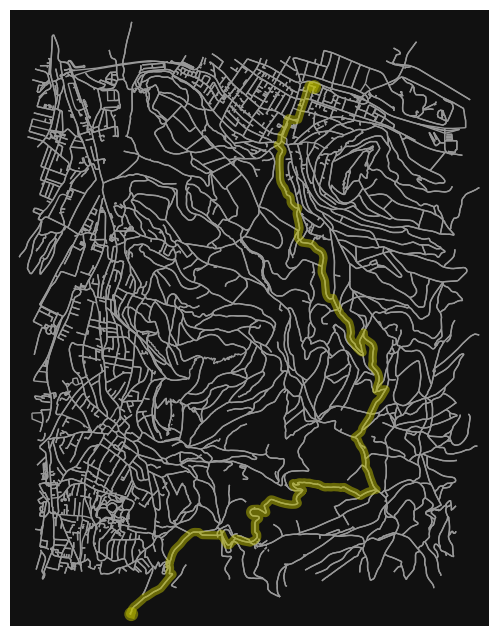

In [11]:
route = ox.routing._single_shortest_path(G, orig=start_point, dest=end_point, weight="forecast[{start_zeit}]")
fig, ax = ox.plot.plot_graph_route(G, route, route_color="y", route_linewidth=6, node_size=0)

In [ ]:
print(route)

# 4.2 Routing (Custom)

In [ ]:
# TODO

# Exkurs Graph Projezieren

In [ ]:
# G = ox.projection.project_graph(G)
print(G.graph['crs'])